In [6]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

# Single IV

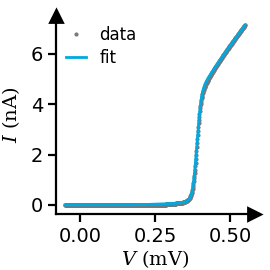

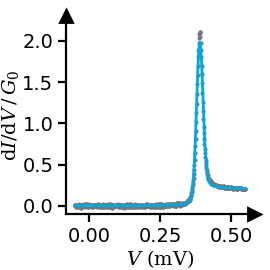

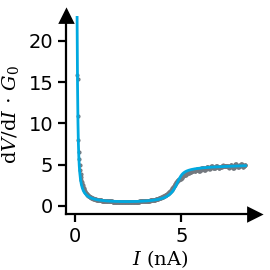

In [125]:
# load data
data = np.load("single_iv/fit.npz")

GN_G0 = data["GN_G0"]
T_K = data["T_K"]
Delta_meV = data["Delta_meV"]
gamma_meV = data["gamma_meV"]
sigmaV_mV = data["sigmaV_mV"]

V_mV = data["V_mV"]
Iexp_nA = data["Iexp_nA"]
Ifit_nA = data["Ifit_nA"]
dGexp_G0 = np.gradient(Iexp_nA, V_mV) / sc.G0_muS
dGfit_G0 = np.gradient(Ifit_nA, V_mV) / sc.G0_muS
dRexp_R0 = np.gradient(V_mV, Iexp_nA) * sc.G0_muS
dRfit_R0 = np.gradient(V_mV, Ifit_nA) * sc.G0_muS

Vbins_mV = np.linspace(-0.05, 0.55, 601)
Ibins_nA = np.linspace(0, 8, 401)

dRexp_R0 = sc.bin_y_over_x(dRexp_R0, Iexp_nA, Ibins_nA)
dRfit_R0 = sc.bin_y_over_x(dRfit_R0, Ifit_nA, Ibins_nA)
dGexp_G0 = sc.bin_y_over_x(dGexp_G0, V_mV, Vbins_mV)
dGfit_G0 = sc.bin_y_over_x(dGfit_G0, V_mV, Vbins_mV)
Iexp_nA = sc.bin_y_over_x(Iexp_nA, V_mV, Vbins_mV)
Ifit_nA = sc.bin_y_over_x(Ifit_nA, V_mV, Vbins_mV)
V_mV = Vbins_mV
# iv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.2, 0.2))

ax.plot(
    Vbins_mV,
    Iexp_nA,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Vbins_mV,
    Ifit_nA,
    label="fit",
    color=sc.seeblau100,
)


ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$I\\ \\mathrm{(nA)}$"
title = "tunnelbarrier/highres/single_iv/iv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

# didv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Vbins_mV,
    dGexp_G0,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Vbins_mV,
    dGfit_G0,
    label="fit",
    color=sc.seeblau100,
)
ax.set_ylim(-0.1, 2.3)

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$"
title = "tunnelbarrier/highres/single_iv/didv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

# dvdi
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Ibins_nA,
    dRexp_R0,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Ibins_nA,
    dRfit_R0,
    label="data",
    color=sc.seeblau100,
)

ax.set_ylim(-1, 23)

ylabel = "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$"
xlabel = "$I\\ \\mathrm{(nA)}$"
title = "tunnelbarrier/highres/single_iv/dvdi"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

# Temperature Study

In [ ]:
# Single IV

outdir = "temperature/single-fit"

# load data
data = np.load("temperature/singleiv-fit.npz")

V_mV = data["Vbias_mV"]
Iexp_nA = data["Iexp_nA"]
Ifit_nA = data["Ifit_nA"]

dGexp_G0 = np.gradient(Iexp_nA, V_mV) / sc.G0_muS
dGfit_G0 = np.gradient(Ifit_nA, V_mV) / sc.G0_muS
dRexp_R0 = np.gradient(V_mV, Iexp_nA) * sc.G0_muS
dRfit_R0 = np.gradient(V_mV, Ifit_nA) * sc.G0_muS

Vbins_mV = np.linspace(-0.05, 0.7, 601)
Ibins_nA = np.linspace(0, 9, 401)

from superconductivity.utilities.functions.upsampling import upsample

dRexp_R0 = sc.bin_y_over_x(
    upsample(dRexp_R0, N_up=100), upsample(Iexp_nA, N_up=100), Ibins_nA
)
dRfit_R0 = sc.bin_y_over_x(
    upsample(dRfit_R0, N_up=100), upsample(Ifit_nA, N_up=100), Ibins_nA
)
dGexp_G0 = sc.bin_y_over_x(
    upsample(dGexp_G0, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
dGfit_G0 = sc.bin_y_over_x(
    upsample(dGfit_G0, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
Iexp_nA = sc.bin_y_over_x(
    upsample(Iexp_nA, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
Ifit_nA = sc.bin_y_over_x(
    upsample(Ifit_nA, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
V_mV = Vbins_mV

# iv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.2, 0.2))

ax.plot(
    Vbins_mV,
    Iexp_nA,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Vbins_mV,
    Ifit_nA,
    label="fit",
    color=sc.seeblau100,
)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
ax.set_ylim(-0.5, 9.9)
ax.set_yticks([0, 4, 8])

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$I\\ \\mathrm{(nA)}$"
title = f"tunnelbarrier/highres/{outdir}/iv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()
# didv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Vbins_mV,
    dGexp_G0,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Vbins_mV,
    dGfit_G0,
    label="fit",
    color=sc.seeblau100,
)
ax.set_ylim(-0.1, 0.9)

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$"
title = f"tunnelbarrier/highres/{outdir}/didv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()
# dvdi
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Ibins_nA,
    dRexp_R0,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Ibins_nA,
    dRfit_R0,
    label="data",
    color=sc.seeblau100,
)

ax.set_ylim(-1, 23)

ylabel = "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$"
xlabel = "$I\\ \\mathrm{(nA)}$"
title = f"tunnelbarrier/highres/{outdir}/dvdi"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

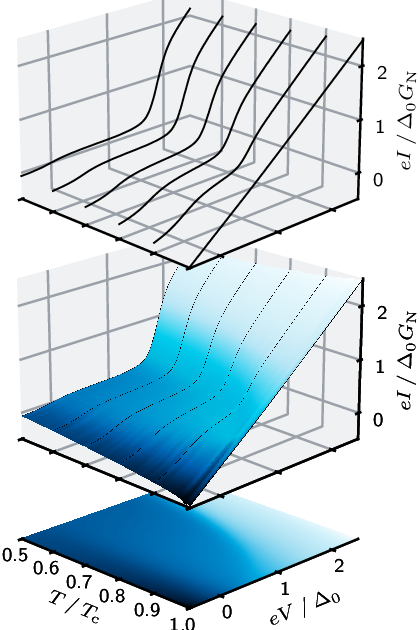

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/temperature/cal_iv/main.png

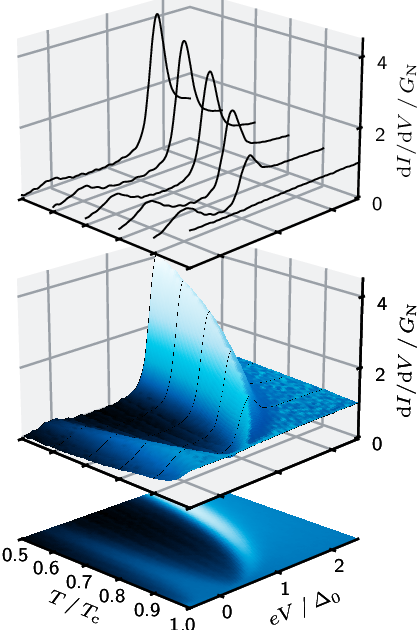

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/temperature/cal_didv/main.png

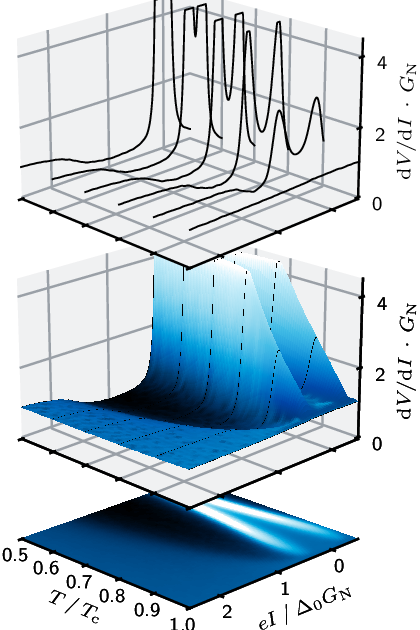

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/temperature/cal_dvdi/main.png

In [93]:
# Temperature Study (cal)
import numpy as np

data = np.load("temperature/cal.npz")

Vbias0 = data["Vbias"]
Ibias0 = data["Ibias"]
Tcal = data["Tcal"]
dGexp = data["dGexp"]
dRexp = data["dRexp"]
Iexp = data["Iexp"]

Vbias = np.linspace(-0.5, 4.5, 501)
Ibias = np.linspace(-0.5, 4.5, 501)

Iexp = sc.bin_y_over_x(Iexp, Vbias0, Vbias, axis=1)
dGexp = sc.bin_y_over_x(dGexp, Vbias0, Vbias, axis=1)
dRexp = sc.bin_y_over_x(dRexp, Ibias0, Ibias, axis=1)

# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Tcal,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    waterfall_traces=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    Abiaslim=(0.5, 1.0),
    Abiasticks=None,
    Vbiaslim=(-0.5, 2.5),
    Vbiasticks=[0, 1, 2],
    Ibiaslim=(-0.5, 2.5),
    Ibiasticks=[0, 1, 2],
    Ilim=(-0.5, 2.5),
    Iticks=[0, 1, 2],
    # dRlim=(-0.05, 5),
    # dRticks=None,
    # dGlim=(-0.05, 5),
    # dGticks=None,
    Alabel="$T\\,/\\,T_\\mathrm{c}$",
    name="cal",
    sub_dir="tunnelbarrier/highres/temperature",
)

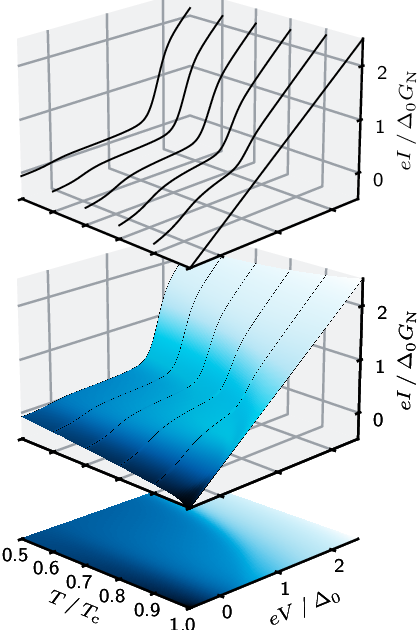

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/temperature/sim_iv/main.png

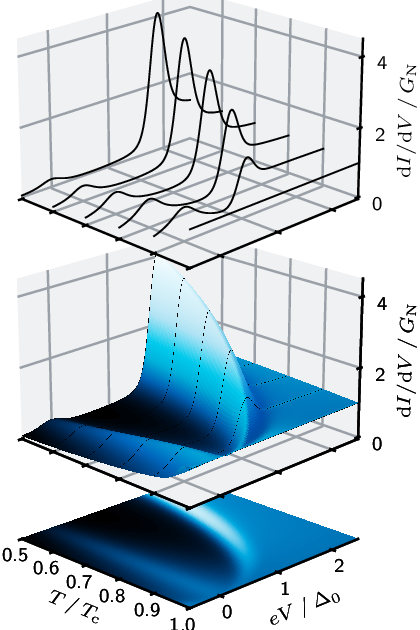

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/temperature/sim_didv/main.png

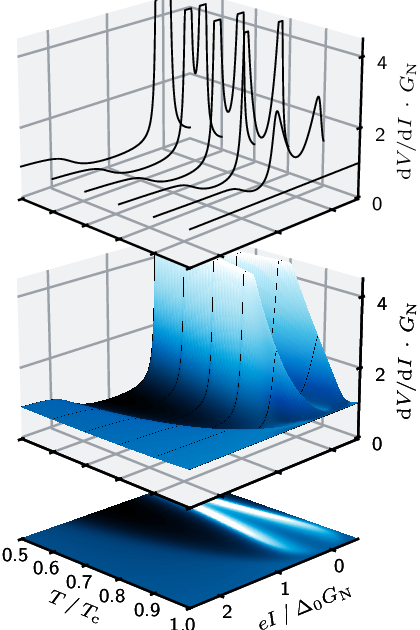

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/temperature/sim_dvdi/main.png

In [122]:
# Temperature Study (Sim)
import numpy as np

data = np.load("temperature/sim.npz")

Vbias = data["Vbias"]
Ibias = data["Ibias"]
Tcal = data["Tsim"]
dGexp = data["dGsim"]
dRexp = data["dRsim"]
Iexp = data["Isim"]

# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Tcal,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    waterfall_traces=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    Abiaslim=(0.5, 1.0),
    Abiasticks=None,
    Vbiaslim=(-0.5, 2.5),
    Vbiasticks=[0, 1, 2],
    Ibiaslim=(-0.5, 2.5),
    Ibiasticks=[0, 1, 2],
    Ilim=(-0.5, 2.5),
    Iticks=[0, 1, 2],
    # dRlim=(-0.05, 5),
    # dRticks=None,
    # dGlim=(-0.05, 5),
    # dGticks=None,
    Alabel="$T\\,/\\,T_\\mathrm{c}$",
    name="sim",
    sub_dir="tunnelbarrier/highres/temperature",
)

[ 0.28190411  1.25647308  1.00228235 -0.09291676]
[0.00174765 0.00257247 0.00400056 0.00361448]


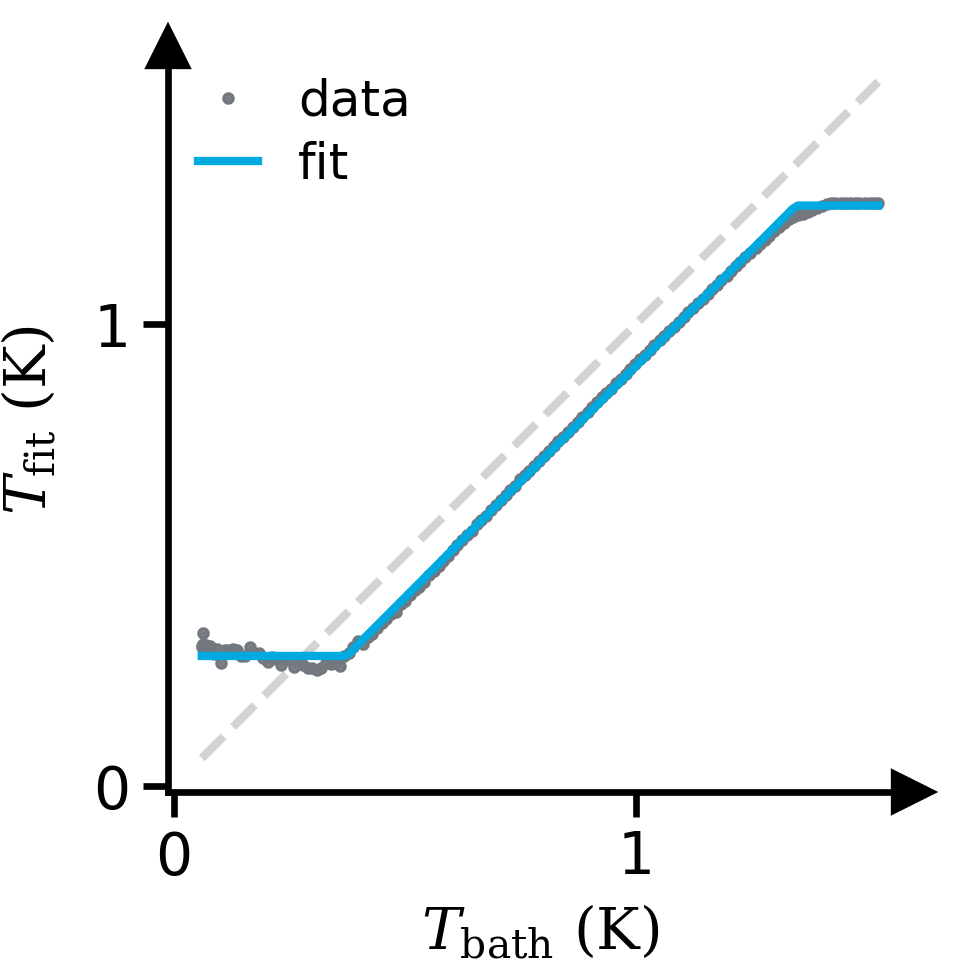

In [3]:
# Temperature Study (fit)
from scipy.optimize import curve_fit

data = np.load("temperature/fit.npz")

GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

Tbath_K = data["Tbath_K"]
Tfit_K = data["Tfit_K"]
uTfit_K = data["uTfit_K"]

# plot data
fig, ax = sc.get_figure(figsize=(1.6, 1.6), padding=(0.2, 0.2))


def calibrate_T(x, Tbase_K, Tc_K, eta_T, Toff_K):
    return np.clip(eta_T * x + Toff_K, Tbase_K, Tc_K)


ax.plot(Tbath_K, Tfit_K, ".", color=sc.seegrau100, label="data")

popt, pcov = curve_fit(
    calibrate_T,
    Tbath_K,
    Tfit_K,
    p0=[0.3, 1.2, 1.0, 0.0],
    bounds=([0.0, 1.0, 0.9, -1.0], [1.0, 1.5, 1.1, 1.0]),
)
perr = np.sqrt(np.diag(pcov))
print(popt)
print(perr)


ax.plot(Tbath_K, calibrate_T(Tbath_K, *popt), "-", color=sc.seeblau100, label="fit")

ax.plot(
    Tbath_K,
    Tbath_K,
    "--",
    color="lightgrey",
    zorder=-10,
)

ax.legend(
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

xlabel = "$T_\\mathrm{bath}\\ \\mathrm{(K)}$"
ylabel = "$T_\\mathrm{fit}\\ \\mathrm{(K)}$"
title = "tunnelbarrier/highres/temperature/fit"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

Tbase_K 0.2821604942601643 0.01866926045180616
Tcritical_K 1.2611020935028985 0.016131157467138363
Toff_K -0.06892914923022378 0.0022648444429189908
alphaT 0.9807989760248529 0.0019842007738515113


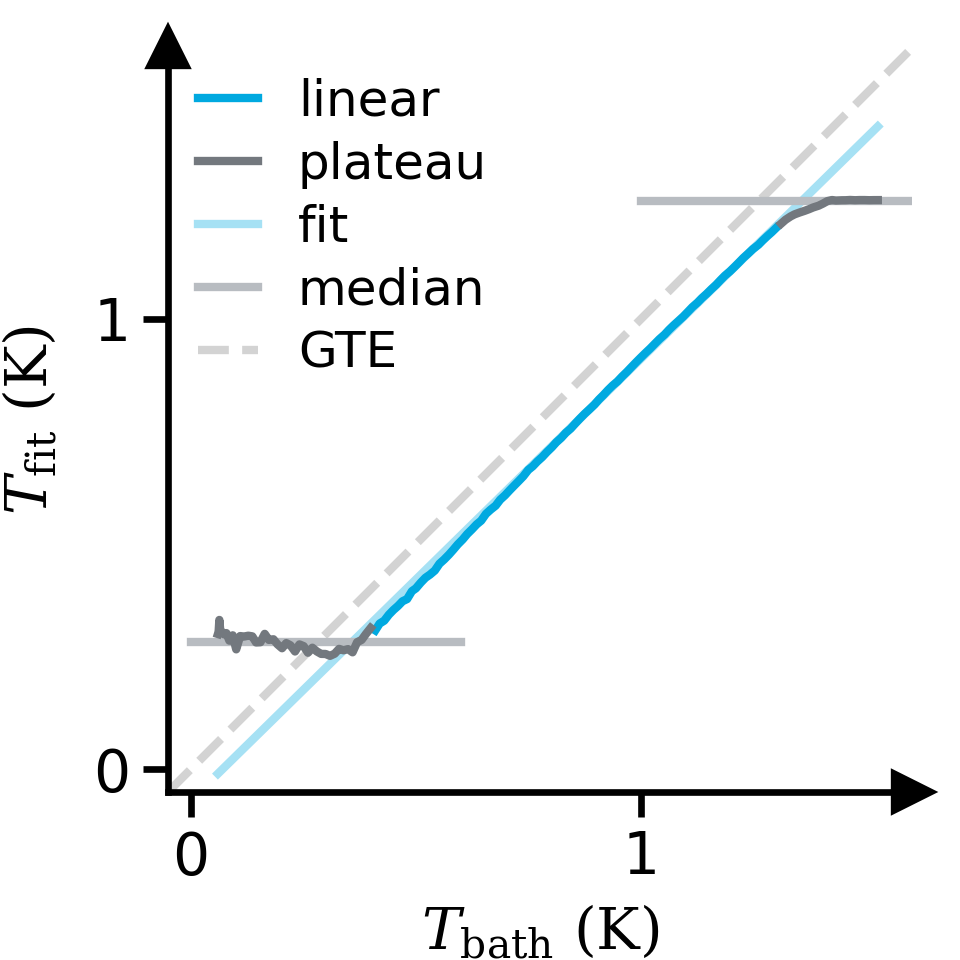

In [ ]:
# # Temperature Study (fit)
# data = np.load("temperature/eva.npz")
# Pheater_uW = data["Pheater_uW"]


# data = np.load("temperature/fit.npz")

# GN_G0 = data["GN_G0"]
# Delta_meV = data["Delta_meV"]

# Tbath_K = data["Tbath_K"]
# Tfit_K = data["Tfit_K"]
# uTfit_K = data["uTfit_K"]

# Tcritical_K = data["Tcritical_K"]
# uTcritical_K = data["uTcritical_K"]
# Tbase_K = data["Tbase_K"]
# uTbase_K = data["uTbase_K"]
# Toff_K = data["Toff_K"]
# uToff_K = data["uToff_K"]
# alphaT = data["alphaT"]
# ualphaT = data["ualphaT"]

# mask_lower = data["mask_lower"]
# mask_upper = data["mask_upper"]
# mask_lin = data["mask_lin"]

# print("Tbase_K", Tbase_K, uTbase_K)
# print("Tcritical_K", Tcritical_K, uTcritical_K)
# print("Toff_K", Toff_K, uToff_K)
# print("alphaT", alphaT, ualphaT)

# # plot data
# fig, ax = sc.get_figure(figsize=(1.6, 1.6), padding=(0.2, 0.2))

# xlim = [-0.05, 1.6]
# ylim = xlim

# # data

# # linear
# ax.plot(
#     Tbath_K[mask_lin],
#     Tfit_K[mask_lin],
#     "-",
#     color=sc.seeblau100,
#     label="linear",
#     zorder=1,
# )
# # ax.fill_between(
# #     Tbath_K[mask_lin],
# #     +Tfit_K[mask_lin] - 2 * uTfit_K[mask_lin],
# #     +Tfit_K[mask_lin] + 2 * uTfit_K[mask_lin],
# #     color=sc.seeblau100,
# #     alpha=0.5,
# #     edgecolor=None,
# #     zorder=-1,
# # )

# # upper
# ax.plot(
#     Tbath_K[mask_upper],
#     Tfit_K[mask_upper],
#     "-",
#     color=sc.seegrau100,
#     label="plateau",
#     zorder=1,
# )
# # ax.fill_between(
# #     Tbath_K[mask_upper],
# #     +Tfit_K[mask_upper] - 2 * uTfit_K[mask_upper],
# #     +Tfit_K[mask_upper] + 2 * uTfit_K[mask_upper],
# #     color=sc.seegrau100,
# #     alpha=0.5,
# #     edgecolor=None,
# #     zorder=-1,
# # )

# # lower
# ax.plot(
#     Tbath_K[mask_lower],
#     Tfit_K[mask_lower],
#     "-",
#     color=sc.seegrau100,
#     zorder=1,
# )
# # ax.fill_between(
# #     Tbath_K[mask_lower],
# #     +Tfit_K[mask_lower] - 2 * uTfit_K[mask_lower],
# #     +Tfit_K[mask_lower] + 2 * uTfit_K[mask_lower],
# #     color=sc.seegrau100,
# #     alpha=0.5,
# #     edgecolor=None,
# #     zorder=-1,
# # )


# # fits
# def calibration_T(T: NDArray64, T_off: float, alpha: float):
#     T = T_off + alpha * T
#     return T


# ax.plot(
#     Tbath_K,
#     calibration_T(Tbath_K, Toff_K, alphaT),
#     color=sc.seeblau35,
#     label="fit",
#     zorder=0,
# )

# # n = 100_000
# # rand0 = np.random.normal(Toff_K, uToff_K, n)
# # rand1 = np.random.normal(alphaT, ualphaT, n)
# # curves = np.array([calibration_T(Tbath_K, a, b) for a, b in zip(rand0, rand1)])
# # y_best = calibration_T(Tbath_K, Toff_K, alphaT)
# # lo, hi = np.percentile(curves, [4.5, 95.5], axis=0)  # ~1 sigma band
# # ax.fill_between(
# #     Tbath_K,
# #     lo,
# #     hi,
# #     color=[*sc.seegrau65, 0.5],
# #     edgecolor=None,
# # )

# ax.plot(
#     [1.0, xlim[1]],
#     [Tcritical_K, Tcritical_K],
#     color=sc.seegrau35,
#     label="median",
#     zorder=0,
# )
# # ax.fill_between(
# #     [1.0, xlim[1]],
# #     [Tcritical_K - uTcritical_K, Tcritical_K - uTcritical_K],
# #     [Tcritical_K + uTcritical_K, Tcritical_K + uTcritical_K],
# #     color=sc.seegrau100,
# #     alpha=0.5,
# #     edgecolor=None,
# #     zorder=-1,
# # )

# ax.plot(
#     [0, xlim[1] - 1.0],
#     [Tbase_K, Tbase_K],
#     color=sc.seegrau35,
#     zorder=0,
# )
# # ax.fill_between(
# #     [0, xlim[1] - 1.0],
# #     [Tbase_K - uTbase_K, Tbase_K - uTbase_K],
# #     [Tbase_K + uTbase_K, Tbase_K + uTbase_K],
# #     color=sc.seegrau100,
# #     alpha=0.5,
# #     edgecolor=None,
# #     zorder=-1,
# # )

# # guide to the eye
# ax.plot(
#     xlim,
#     xlim,
#     "--",
#     color="lightgrey",
#     zorder=-10,
#     label="GTE",
# )

# ax.set_xlim(xlim)
# ax.set_ylim(ylim)
# ax.set_xticks([0, 1])
# ax.set_yticks([0, 1])

# ax.legend(
#     handlelength=1.2,
#     loc="upper left",
#     frameon=False,
#     fontsize=6,
#     title_fontsize=6,
#     ncols=1,
#     columnspacing=0.8,
#     borderpad=0.1,  # reduces padding inside the legend box
#     labelspacing=0.3,  # reduces vertical spacing between items
#     handletextpad=0.8,  # reduces spacing between line and label
#     # bbox_to_anchor=(1.1, 1.1),
# )

# xlabel = "$T_\\mathrm{bath}\\ \\mathrm{(K)}$"
# ylabel = "$T_\\mathrm{fit}\\ \\mathrm{(K)}$"
# title = "tunnelbarrier/highres/temperature/fit"

# sc.theory_layout(fig, ax, title, xlabel, ylabel)
# plt.show()

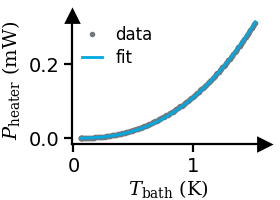

In [90]:
# Heater Calibration
data = np.load("temperature/eva.npz")
Pheater_uW = data["Pheater_uW"]


data = np.load("temperature/fit.npz")

GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

Tbath_K = data["Tbath_K"]
Tfit_K = data["Tfit_K"]
uTfit_K = data["uTfit_K"]

Tcritical_K = data["Tcritical_K"]
uTcritical_K = data["uTcritical_K"]
Tbase_K = data["Tbase_K"]
uTbase_K = data["uTbase_K"]
Toff_K = data["Toff_K"]
uToff_K = data["uToff_K"]
alphaT = data["alphaT"]
ualphaT = data["ualphaT"]

mask_lower = data["mask_lower"]
mask_upper = data["mask_upper"]
mask_lin = data["mask_lin"]

fig, ax = sc.get_figure(figsize=(1.4, 1.0), padding=(0.28, 0.2))

ax.plot(
    Tbath_K,
    Pheater_uW * 1e-3,
    ".",
    ms=2,
    color=sc.seegrau100,
    zorder=-1,
    label="data",
)
ax.plot(Tbath_K, 0.11 * Tbath_K**2.5, color=sc.seeblau100, zorder=0, label="fit")

ax.legend(
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)

xlabel = "$T_\\mathrm{bath}\\ \\mathrm{(K)}$"
ylabel = "$P_\\mathrm{heater}\\ \\mathrm{(mW)}$"
title = "tunnelbarrier/highres/temperature/heater"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

# Amplitude Studies

In [ ]:
# Single IV

outdir = "amp_18.3GHz/single-fit"

# load data
data = np.load("amp_18.3GHz/singleiv-fit.npz")

V_mV = data["Vbias_mV"]
Iexp_nA = data["Iexp_nA"]
Ifit_nA = data["Ifit_nA"]

dGexp_G0 = np.gradient(Iexp_nA, V_mV) / sc.G0_muS
dGfit_G0 = np.gradient(Ifit_nA, V_mV) / sc.G0_muS
dRexp_R0 = np.gradient(V_mV, Iexp_nA) * sc.G0_muS
dRfit_R0 = np.gradient(V_mV, Ifit_nA) * sc.G0_muS

Vbins_mV = np.linspace(-0.05, 0.7, 601)
Ibins_nA = np.linspace(0, 9, 401)

from superconductivity.utilities.functions.upsampling import upsample

dRexp_R0 = sc.bin_y_over_x(
    upsample(dRexp_R0, N_up=100), upsample(Iexp_nA, N_up=100), Ibins_nA
)
dRfit_R0 = sc.bin_y_over_x(
    upsample(dRfit_R0, N_up=100), upsample(Ifit_nA, N_up=100), Ibins_nA
)
dGexp_G0 = sc.bin_y_over_x(
    upsample(dGexp_G0, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
dGfit_G0 = sc.bin_y_over_x(
    upsample(dGfit_G0, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
Iexp_nA = sc.bin_y_over_x(
    upsample(Iexp_nA, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
Ifit_nA = sc.bin_y_over_x(
    upsample(Ifit_nA, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
V_mV = Vbins_mV

# iv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.2, 0.2))

ax.plot(
    Vbins_mV,
    Iexp_nA,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Vbins_mV,
    Ifit_nA,
    label="fit",
    color=sc.seeblau100,
)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
ax.set_ylim(-0.5, 9.9)
ax.set_yticks([0, 4, 8])

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$I\\ \\mathrm{(nA)}$"
title = f"tunnelbarrier/highres/{outdir}/iv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()
# didv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Vbins_mV,
    dGexp_G0,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Vbins_mV,
    dGfit_G0,
    label="fit",
    color=sc.seeblau100,
)
ax.set_ylim(-0.1, 0.75)

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$"
title = f"tunnelbarrier/highres/{outdir}/didv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()
# dvdi
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Ibins_nA,
    dRexp_R0,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Ibins_nA,
    dRfit_R0,
    label="data",
    color=sc.seeblau100,
)

ax.set_ylim(-1, 23)

ylabel = "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$"
xlabel = "$I\\ \\mathrm{(nA)}$"
title = f"tunnelbarrier/highres/{outdir}/dvdi"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

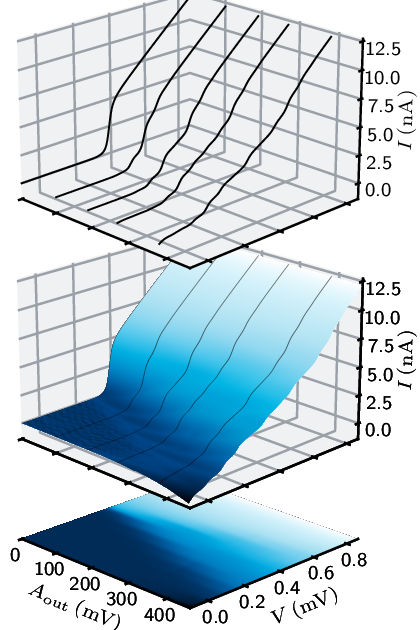

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_18.3GHz/exp_iv/main.png

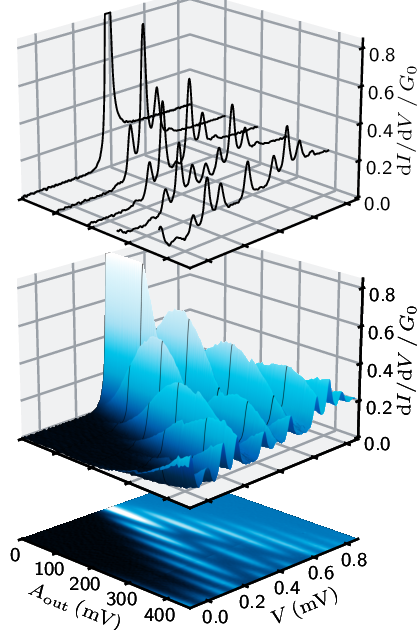

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_18.3GHz/exp_didv/main.png

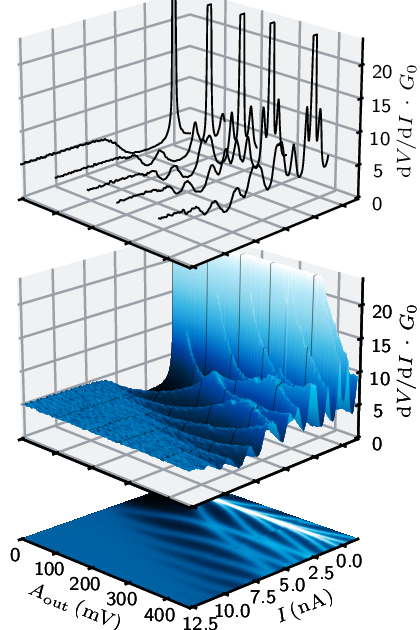

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_18.3GHz/exp_dvdi/main.png

In [2]:
# Amplitude Study @ 18.3 GHz (exp)
import numpy as np

data = np.load("amp_18.3GHz/eva.npz")

Vbias_mV = data["Vbias_mV"]
Ibias_nA = data["Ibias_nA"]
Aout_mV = data["Aout_mV"]
dGexp_G0 = data["dGexp_G0"]
dRexp_R0 = data["dRexp_R0"]
Iexp_nA = data["Iexp_nA"]
nu_GHz = data["nu_GHz"]

# restoring dimensions
eta = 0.002173  # (3)
GN_G0: float = 0.18877592218372993
Delta_meV: float = 0.19345000789195935

Vbias = np.linspace(-0.5, 4.5, 501) * Delta_meV
Ibias = np.linspace(-0.5, 4.5, 501) * (GN_G0 * sc.G0_muS * Delta_meV)

Iexp = sc.bin_y_over_x(Iexp_nA, Vbias_mV, Vbias, axis=1)
dGexp = sc.bin_y_over_x(dGexp_G0, Vbias_mV, Vbias, axis=1)
dRexp = sc.bin_y_over_x(dRexp_R0, Ibias_nA, Ibias, axis=1)

Aintrest_mV = [
    0.0,
    98.86444286728177,
    190.27679205110007,
    271.7530163236338,
    378.06955287437904,
]

Vbiaslim = (-0.5 * Delta_meV, 4.5 * Delta_meV)
Abiaslim = (0.0, 458.5521646557843)
Ibiaslim = (
    -0.5 * (GN_G0 * sc.G0_muS * Delta_meV),
    4.5 * (GN_G0 * sc.G0_muS * Delta_meV),
)
Ilim = (-0.5 * (GN_G0 * sc.G0_muS * Delta_meV), 4.5 * (GN_G0 * sc.G0_muS * Delta_meV))
dGlim = (-0.05 * GN_G0, 4.5 * GN_G0)
dRlim = (-0.05 / GN_G0, 4.5 / GN_G0)

Vlabel = "$V\\,\\mathrm{(mV)}$"
Alabel = "$A_\\mathrm{out}\\,\\mathrm{(mV)}$"
Ilabel = "$I\\,\\mathrm{(nA)}$"
dGlabel = r"$\mathrm{d}I/\mathrm{d}V\,/\,G_\mathrm{0}$"
dRlabel = r"$\mathrm{d}V/\mathrm{d}I\,\cdot\,G_\mathrm{0}$"

# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias_mV,
    Abias=Aout_mV,
    Ibias=Ibias_nA,
    Iexp=Iexp_nA,
    dGexp=dGexp_G0,
    dRexp=dRexp_R0,
    waterfall_traces=Aintrest_mV,
    Vbiaslim=Vbiaslim,
    Abiaslim=Abiaslim,
    Ibiaslim=Ibiaslim,
    Ilim=Ilim,
    dGlim=dGlim,
    dRlim=dRlim,
    Vbiasticks=None,
    Abiasticks=None,
    Ibiasticks=None,
    Iticks=None,
    dGticks=None,
    dRticks=None,
    Vlabel=Vlabel,
    Alabel=Alabel,
    Ilabel=Ilabel,
    dGlabel=dGlabel,
    dRlabel=dRlabel,
    name="exp",
    sub_dir="tunnelbarrier/highres/amp_18.3GHz/",
)

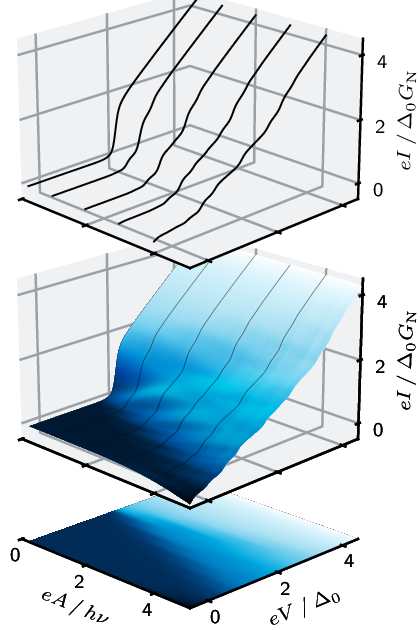

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_18.3GHz/cal_iv/main.png

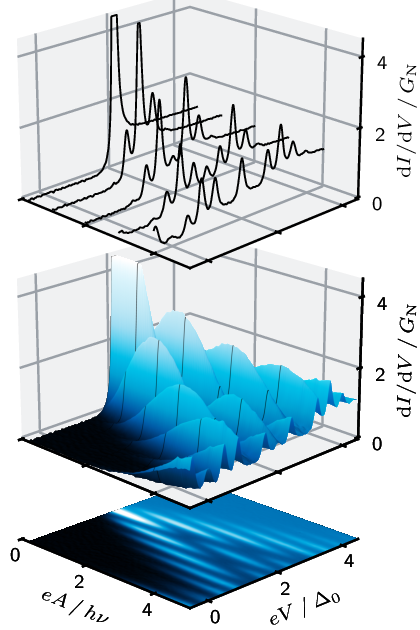

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_18.3GHz/cal_didv/main.png

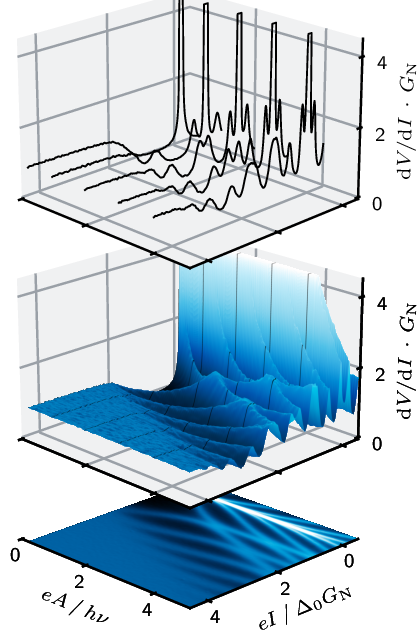

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_18.3GHz/cal_dvdi/main.png

In [3]:
# Amplitude Study @ 18.3 GHz (cal)
import numpy as np

data = np.load("amp_18.3GHz/cal.npz")

Vbias0 = data["Vbias"]
Ibias0 = data["Ibias"]
Abias = data["Abias"]

dGexp = data["dGexp"]
dRexp = data["dRexp"]
Iexp = data["Iexp"]

nu_GHz = data["nu_GHz"]
GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

Abias0 = Abias[np.logical_not(np.isnan(np.mean(Iexp, axis=1)))]

Vbias = np.linspace(-0.5, 4.5, 501)
Ibias = np.linspace(-0.5, 4.5, 501)
from superconductivity.utilities.functions.upsampling import upsample

Iexp = sc.bin_y_over_x(upsample(Iexp), upsample(Vbias0), Vbias, axis=1)
dGexp = sc.bin_y_over_x(upsample(dGexp), upsample(Vbias0), Vbias, axis=1)
dRexp = sc.bin_y_over_x(upsample(dRexp), upsample(Ibias0), Ibias, axis=1)

# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Abias,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    waterfall_traces=[0.2, 1.0, 2.0, 3.0, 4.0],
    Ilim=(-0.5, 4.5),
    name="cal",
    sub_dir="tunnelbarrier/highres/amp_18.3GHz",
)

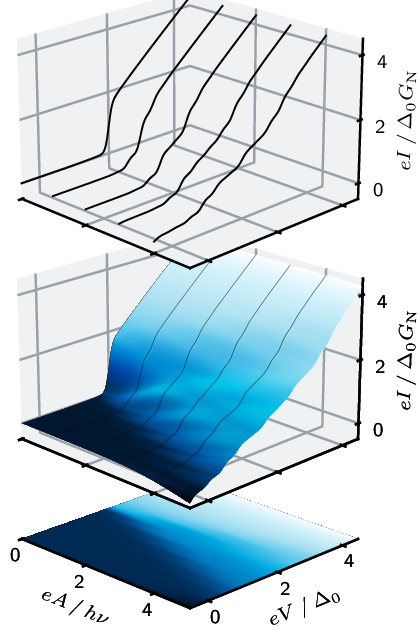

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_18.3GHz/sim_iv/main.png

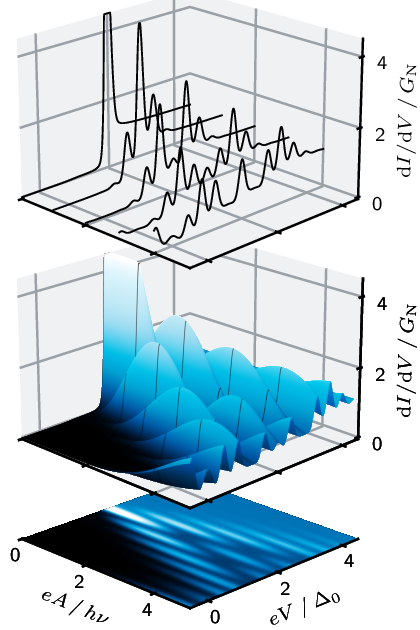

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_18.3GHz/sim_didv/main.png

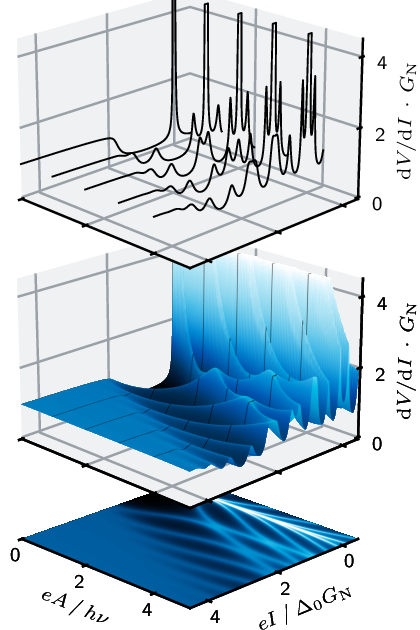

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_18.3GHz/sim_dvdi/main.png

In [4]:
# Amplitude Study @ 18.3 GHz (sim)
import numpy as np

data = np.load("amp_18.3GHz/sim.npz")

Vbias0 = data["Vbias"]
Ibias0 = data["Ibias"]
Abias = data["Abias"]
Isim = data["Isim"]
dGsim = data["dGsim"]
dRsim = data["dRsim"]
nu_GHz = data["nu_GHz"]
GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

Vbias = np.linspace(-0.5, 4.5, 501)
Ibias = np.linspace(-0.5, 4.5, 501)

Isim = sc.bin_y_over_x(Isim, Vbias0, Vbias, axis=1)
dGsim = sc.bin_y_over_x(dGsim, Vbias0, Vbias, axis=1)
dRsim = sc.bin_y_over_x(dRsim, Ibias0, Ibias, axis=1)

# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Abias,
    Ibias=Ibias,
    Iexp=Isim,
    dGexp=dGsim,
    dRexp=dRsim,
    waterfall_traces=[0.0, 1.0, 2.0, 3.0, 4.0],
    Ilim=(-0.5, 4.5),
    name="sim",
    sub_dir="tunnelbarrier/highres/amp_18.3GHz",
)

eta 0.000838725601648771 3.255273028117284e-06


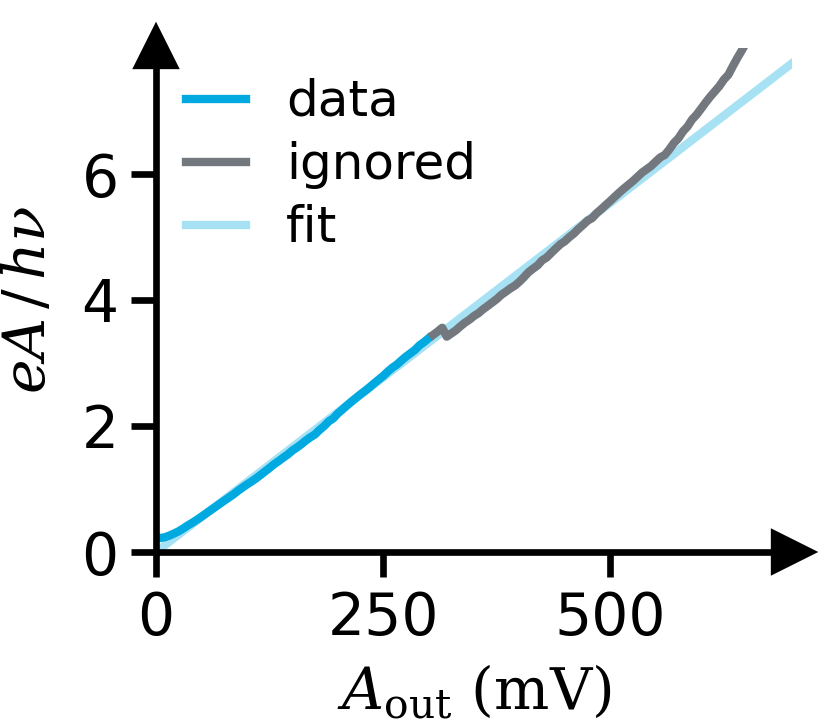

In [6]:
# Amplitude Study @ 18.3 GHz (fit)
import numpy as np
from scipy.optimize import curve_fit
import superconductivity as sc

data = np.load("amp_18.3GHz/fit.npz")

Aout_mV = data["Aout_mV"]
Afit_mV = data["Afit_mV"]
uAfit_mV = data["uAfit_mV"]
Tfit_K = data["Tfit_K"]
uTfit_K = data["uTfit_K"]
nu_GHz = data["nu_GHz"]
GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

mask_lin = Aout_mV <= 300
mask_other = Aout_mV > 300

figsize = (1.4, 1.2)
fig, ax = sc.get_figure(
    figsize=figsize,
    padding=(0.18, 0.2),
)

ax.plot(
    Aout_mV[mask_lin],
    Afit_mV[mask_lin] / (sc.h_pVs * nu_GHz),
    "-",
    color=sc.seeblau100,
    label="data",
    zorder=1,
)
ax.plot(
    Aout_mV[mask_other],
    Afit_mV[mask_other] / (sc.h_pVs * nu_GHz),
    "-",
    color=sc.seegrau100,
    label="ignored",
    zorder=1,
)


def linear(x, a):
    return a * x


eta, ueta = curve_fit(linear, Aout_mV[mask_lin], Afit_mV[mask_lin])
ueta = np.sqrt(np.diag(ueta))

eta = eta[0]
ueta = ueta[0]
print("eta", eta, ueta)
# print(
#     "eta_median",
#     np.nanmedian(Afit_mV[mask_lin] / Aout_mV[mask_lin]),
#     np.nanstd(Afit_mV[mask_lin] / Aout_mV[mask_lin]),
# )

ax.plot(
    Aout_mV,
    Aout_mV * eta / (sc.h_pVs * nu_GHz),
    color=sc.seeblau35,
    label="fit",
    zorder=0,
)

ax.legend(
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)

ax.set_ylim(0, 8)
ax.set_yticks([0, 2, 4, 6])
ax.set_xlim(0, 700)


xlabel = "$A_\\mathrm{out}\\ \\mathrm{(mV)}$"
ylabel = "$eA\\,/\\,h\\nu$"
title = "tunnelbarrier/highres/amp_18.3GHz/fit"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

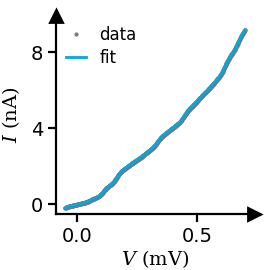

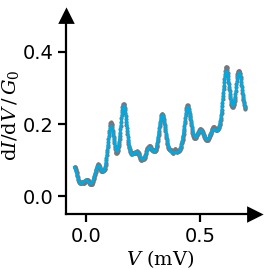

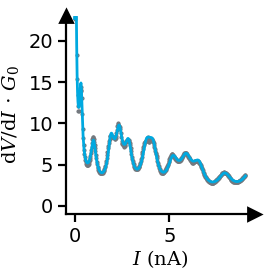

In [4]:
# Amplitude Study @ 13.6 GHz (single)

outdir = "amp_13.6GHz/single-fit"

# load data
data = np.load("amp_13.6GHz/singleiv-fit.npz")

V_mV = data["Vbias_mV"]
Iexp_nA = data["Iexp_nA"]
Ifit_nA = data["Ifit_nA"]

dGexp_G0 = np.gradient(Iexp_nA, V_mV) / sc.G0_muS
dGfit_G0 = np.gradient(Ifit_nA, V_mV) / sc.G0_muS
dRexp_R0 = np.gradient(V_mV, Iexp_nA) * sc.G0_muS
dRfit_R0 = np.gradient(V_mV, Ifit_nA) * sc.G0_muS

Vbins_mV = np.linspace(-0.05, 0.7, 601)
Ibins_nA = np.linspace(0, 9, 401)

from superconductivity.utilities.functions.upsampling import upsample

dRexp_R0 = sc.bin_y_over_x(
    upsample(dRexp_R0, N_up=100), upsample(Iexp_nA, N_up=100), Ibins_nA
)
dRfit_R0 = sc.bin_y_over_x(
    upsample(dRfit_R0, N_up=100), upsample(Ifit_nA, N_up=100), Ibins_nA
)
dGexp_G0 = sc.bin_y_over_x(
    upsample(dGexp_G0, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
dGfit_G0 = sc.bin_y_over_x(
    upsample(dGfit_G0, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
Iexp_nA = sc.bin_y_over_x(
    upsample(Iexp_nA, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
Ifit_nA = sc.bin_y_over_x(
    upsample(Ifit_nA, N_up=100), upsample(V_mV, N_up=100), Vbins_mV
)
V_mV = Vbins_mV

# iv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.2, 0.2))

ax.plot(
    Vbins_mV,
    Iexp_nA,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Vbins_mV,
    Ifit_nA,
    label="fit",
    color=sc.seeblau100,
)

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)
ax.set_ylim(-0.5, 9.9)
ax.set_yticks([0, 4, 8])

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$I\\ \\mathrm{(nA)}$"
title = f"tunnelbarrier/highres/{outdir}/iv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()
# didv
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Vbins_mV,
    dGexp_G0,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Vbins_mV,
    dGfit_G0,
    label="fit",
    color=sc.seeblau100,
)
ax.set_ylim(-0.05, 0.5)

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$\\mathrm{d}I/\\mathrm{d}V\\,/\\,G_0$"
title = f"tunnelbarrier/highres/{outdir}/didv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()
# dvdi
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.25, 0.2))

ax.plot(
    Ibins_nA,
    dRexp_R0,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Ibins_nA,
    dRfit_R0,
    label="data",
    color=sc.seeblau100,
)

ax.set_ylim(-1, 23)

ylabel = "$\\mathrm{d}V/\\mathrm{d}I\\,\\cdot\\,G_0$"
xlabel = "$I\\ \\mathrm{(nA)}$"
title = f"tunnelbarrier/highres/{outdir}/dvdi"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

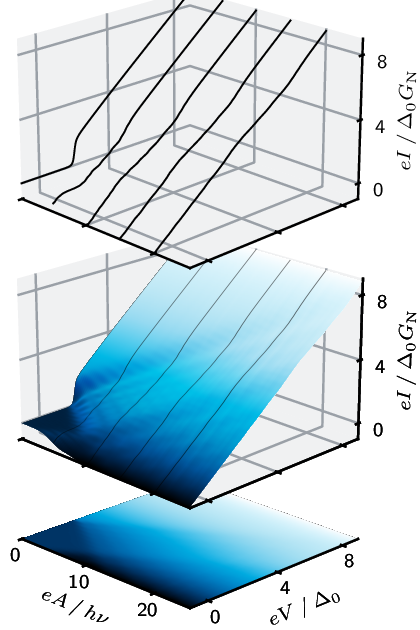

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_13.6GHz/cal_iv/main.png

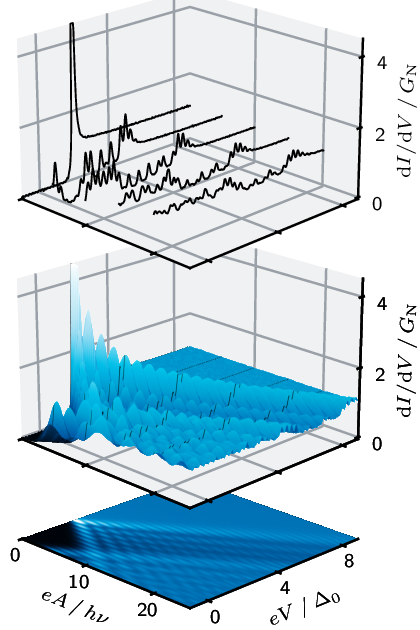

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_13.6GHz/cal_didv/main.png

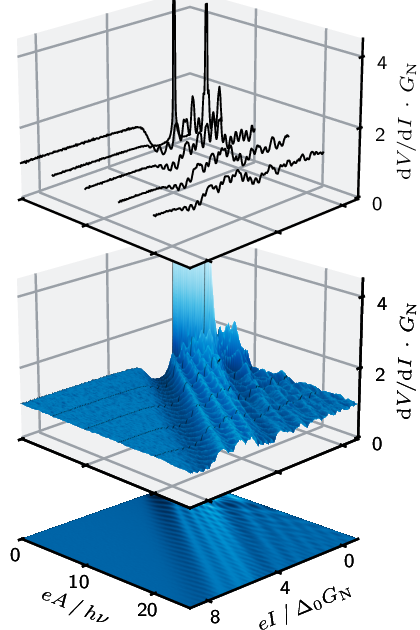

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_13.6GHz/cal_dvdi/main.png

In [7]:
# Amplitude Study @ 13.6 GHz (cal)
import numpy as np

data = np.load("amp_13.6GHz/cal.npz")

Vbias0 = data["Vbias"]
Ibias0 = data["Ibias"]
Abias = data["Abias"]

dGexp = data["dGexp"]
dRexp = data["dRexp"]
Iexp = data["Iexp"]

nu_GHz = data["nu_GHz"]
GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

Abias0 = Abias[np.logical_not(np.isnan(np.mean(Iexp, axis=1)))]

Vbias = np.linspace(-1.0, 9.0, 501)
Ibias = np.linspace(-1.0, 9.0, 501)
from superconductivity.utilities.functions.upsampling import upsample

Iexp = sc.bin_y_over_x(upsample(Iexp), upsample(Vbias0), Vbias, axis=1)
dGexp = sc.bin_y_over_x(upsample(dGexp), upsample(Vbias0), Vbias, axis=1)
dRexp = sc.bin_y_over_x(upsample(dRexp), upsample(Ibias0), Ibias, axis=1)

# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Abias,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    Vbiaslim=(-1, 9),
    Vbiasticks=[0, 4, 8],
    Ibiaslim=(-1, 9),
    Ibiasticks=[0, 4, 8],
    Ilim=(-1, 9),
    Iticks=[0, 4, 8],
    Abiaslim=(0, 25),
    Abiasticks=[0, 10, 20],
    waterfall_traces=[0, 5, 10, 15, 20],
    surface_x_oversample=20,
    name="cal",
    sub_dir="tunnelbarrier/highres/amp_13.6GHz",
)

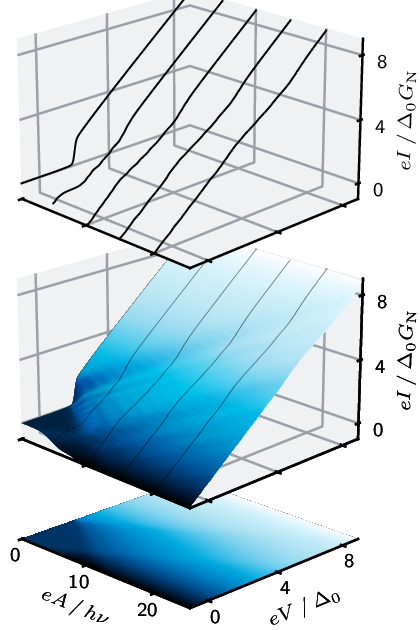

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_13.6GHz/sim_iv/main.png

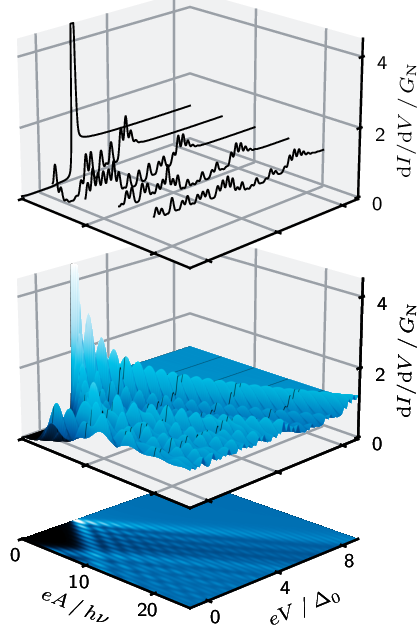

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_13.6GHz/sim_didv/main.png

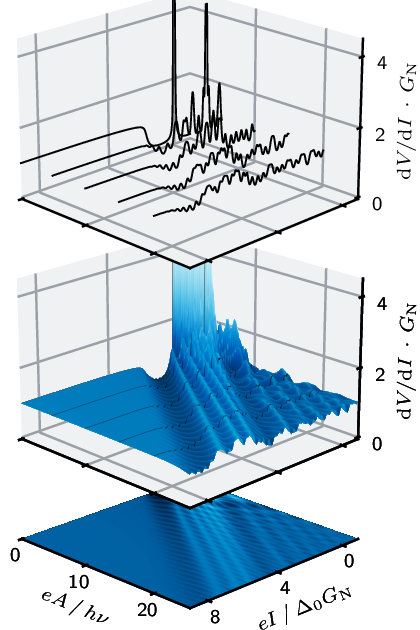

/Users/oliver/Documents/cryolab/dissertation-figures/tunnelbarrier/highres/amp_13.6GHz/sim_dvdi/main.png

In [8]:
# Amplitude Study @ 13.6 GHz (sim)
import numpy as np

data = np.load("amp_13.6GHz/sim.npz")

Vbias = data["Vbias"]
Ibias = data["Ibias"]
Abias = data["Abias"]

dGexp = data["dGsim"]
dRexp = data["dRsim"]
Iexp = data["Isim"]

nu_GHz = data["nu_GHz"]
GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

Abias0 = Abias[np.logical_not(np.isnan(np.mean(Iexp, axis=1)))]

# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Abias,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    Vbiaslim=(-1, 9),
    Vbiasticks=[0, 4, 8],
    Ibiaslim=(-1, 9),
    Ibiasticks=[0, 4, 8],
    Ilim=(-1, 9),
    Iticks=[0, 4, 8],
    Abiaslim=(0, 25),
    Abiasticks=[0, 10, 20],
    waterfall_traces=[0, 5, 10, 15, 20],
    surface_x_oversample=20,
    name="sim",
    sub_dir="tunnelbarrier/highres/amp_13.6GHz",
)

eta 0.00215061235206838 1.4453470273403933e-06


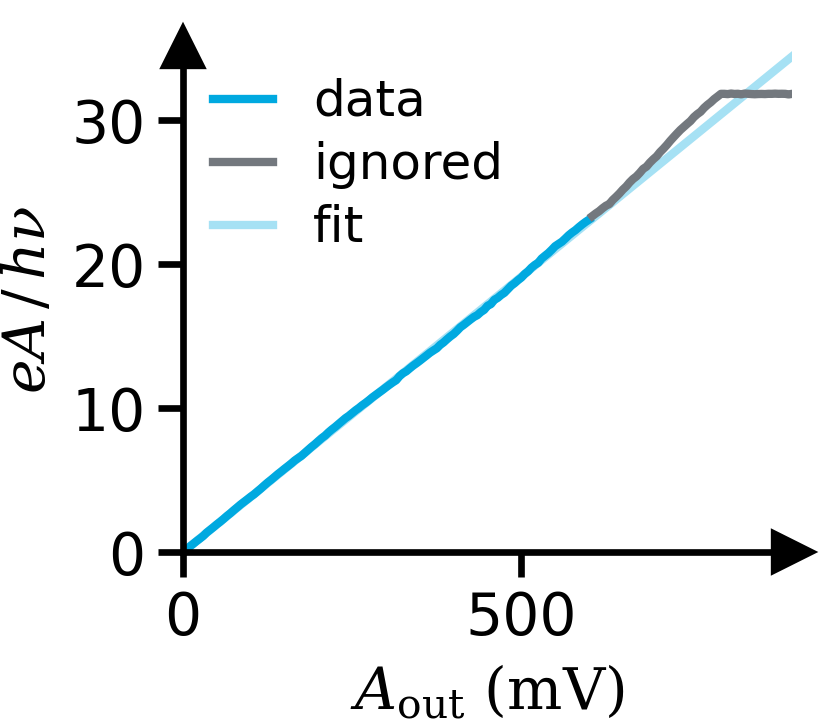

In [ ]:
# Amplitude Study @ 13.6 GHz (fit)
import numpy as np
from scipy.optimize import curve_fit
import superconductivity as sc

data = np.load("amp_13.6GHz/fit.npz")

Aout_mV = data["Aout_mV"]
Afit_mV = data["Afit_mV"]
uAfit_mV = data["uAfit_mV"]
Tfit_K = data["Tfit_K"]
uTfit_K = data["uTfit_K"]
nu_GHz = data["nu_GHz"]
GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

mask_lin = Aout_mV <= 600
mask_other = Aout_mV > 600

figsize = (1.4, 1.2)
fig, ax = sc.get_figure(
    figsize=figsize,
    padding=(0.225, 0.2),
)

ax.plot(
    Aout_mV[mask_lin],
    Afit_mV[mask_lin] / (sc.h_pVs * nu_GHz),
    "-",
    color=sc.seeblau100,
    label="data",
    zorder=1,
)
ax.plot(
    Aout_mV[mask_other],
    Afit_mV[mask_other] / (sc.h_pVs * nu_GHz),
    "-",
    color=sc.seegrau100,
    label="ignored",
    zorder=1,
)


def linear(x, a):
    return a * x


eta, ueta = curve_fit(linear, Aout_mV[mask_lin], Afit_mV[mask_lin])
ueta = np.sqrt(np.diag(ueta))

eta = eta[0]
ueta = ueta[0]
print("eta", eta, ueta)

ax.plot(
    Aout_mV,
    Aout_mV * eta / (sc.h_pVs * nu_GHz),
    color=sc.seeblau35,
    label="fit",
    zorder=0,
)
ax.set_xlim(0, 900)
ax.set_ylim(0, 35)
ax.set_yticks([0, 10, 20, 30])
ax.set_xticks([0, 500])

ax.legend(
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)


xlabel = "$A_\\mathrm{out}\\ \\mathrm{(mV)}$"
ylabel = "$eA\\,/\\,h\\nu$"
title = "tunnelbarrier/highres/amp_13.6GHz/fit"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()